In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Here, I am trying to find the most optimized shipping mode based on the probabilities of the shipment's delivery status. I am taking only label 1 probability by building 4 logistic regression models. One for each shipping mode and then using that for LP problem. End of the notebook are graphs.

In [2]:
df = pd.read_csv('/kaggle/input/logistics-data-containing-real-world-data/incom2024_delay_example_dataset.csv')

# Pre-Processing

In [3]:
# 1) Keep all statuses except ON_HOLD
df = df[df['order_status'] != 'ON_HOLD'].copy()

# 2) Basic clean-up if needed
df = df.dropna(subset=['order_item_total_amount', 'profit_per_order', 'shipping_mode'])

In [4]:
dt = pd.to_datetime(df['order_date'], errors='coerce', utc=True)
df['shipping_date'] = pd.to_datetime(df['shipping_date'], errors='coerce', utc=True)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', utc=True)

In [5]:
# Time features: order_month, order_year

df['order_month'] = dt.dt.month
df['order_year'] = dt.dt.year
df['order_dayofweek'] = dt.dt.dayofweek
df['order_weekofyear'] = dt.dt.isocalendar().week.astype(int)

# Convert date columns to datetime objects (handling potential errors)

# Calculate days to ship, clipping negative values to 0 if they occur
df['days_to_ship'] = (df['shipping_date'] - df['order_date']).dt.days
df['days_to_ship'] = df['days_to_ship'].clip(lower=0)

df["peak_season"] = df["order_month"].between(3, 8).astype(int)

In [6]:
df["month_mode"] = df["order_month"].astype(str) + "_" + df["shipping_mode"]
df["region_mode"] = df["order_region"].astype(str) + "_" + df["shipping_mode"]
df["dow_mode"] = df["order_dayofweek"].astype(str) + "_" + df["shipping_mode"]

# Optimization

## Building 4 logistic regression models

In [7]:
numeric_features = [
    'product_price',
    'order_item_product_price',
    'order_item_quantity',
    'order_item_discount',
    'order_item_discount_rate',
    'order_item_total_amount',
    'sales',
    'sales_per_customer',
    'order_year',
    'order_month',
    'order_dayofweek',
    'days_to_ship',
    'latitude',
    'longitude',
    'peak_season',
]

categorical_features = [
    'customer_country',
    'customer_segment',
    'customer_state',
    'department_id',
    'department_name',
    'category_name',
    'market',
    'payment_type',
    'order_region',
    'order_status',
]

base_features = numeric_features + categorical_features
target = "label"
shipping_modes = df["shipping_mode"].unique().tolist()

In [8]:
from sklearn.model_selection import train_test_split

X = df[base_features]
y = df[target]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

global_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

global_preprocessor.fit(df[base_features])
X_all_transformed = global_preprocessor.transform(df[base_features])



In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Get positional indices for each mode
mode_models = {}

for mode in shipping_modes:

    # boolean mask
    mask = (df["shipping_mode"] == mode)

    # convert mask → positional row numbers
    pos_idx = np.where(mask.values)[0]

    # extract rows using position, NOT df.index
    X_mode = X_all_transformed[pos_idx]
    y_mode = y.values[pos_idx]

    logreg = LogisticRegression(
        multi_class='multinomial',
        class_weight='balanced',
        max_iter=500
    )

    logreg.fit(X_mode, y_mode)
    mode_models[mode] = logreg



print("All 4 mode-specific logistic regression models trained successfully.")


All 4 mode-specific logistic regression models trained successfully.


In [11]:
DELAY_CLASS_INDEX = 2

def get_delay_probs_for_all_modes(row):
    row_df = row[base_features]
    x_trans = global_preprocessor.transform(row_df)

    probs = {}
    for mode, model in mode_models.items():
        p = model.predict_proba(x_trans)[0][DELAY_CLASS_INDEX]
        probs[mode] = p
    return probs

In [12]:
delay_prob_matrix = []

for idx in X_test_full.index:
    row = X_test_full.loc[[idx]]
    probs = get_delay_probs_for_all_modes(row)
    delay_prob_matrix.append(probs)

delay_prob_df = pd.DataFrame(delay_prob_matrix, index=X_test_full.index)
delay_prob_df.head()


,Standard Class,Second Class,First Class,Same Day
1329,0.177716,0.507494,0.998083,0.697205
13676,0.406558,0.499380,0.811086,0.962096
4484,0.283615,0.484694,0.755067,0.019783
1008,0.358451,0.459161,0.978247,0.342143
3369,0.336586,0.583324,0.999632,0.603801


In [13]:
import pandas as pd

# Make sure columns are in a known order
shipping_modes = ["Standard Class", "Second Class", "First Class", "Same Day"]

penalties = {
    "Standard Class": 1.0,
    "Second Class": 1.2,
    "First Class": 1.5,
    "Same Day": 2.0
}

# Expected delay cost = P(delay) * penalty[mode]
cost_matrix = delay_prob_df[shipping_modes].copy()

for mode in shipping_modes:
    cost_matrix[mode] = delay_prob_df[mode] * penalties[mode]


In [14]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 67.1 MB/s eta 0:00:00


In [15]:
import pulp

orders = list(cost_matrix.index)
modes = shipping_modes

# LP model
model = pulp.LpProblem("Shipping_Optimization", pulp.LpMinimize)

# Decision variables: x[o][m] = 1 if order o uses mode m
x = pulp.LpVariable.dicts("assign", (orders, modes), lowBound=0, upBound=1, cat='Binary')

# Objective: minimize total expected delay cost
model += pulp.lpSum(
    x[o][m] * cost_matrix.loc[o, m]
    for o in orders
    for m in modes
)

# Constraints: exactly one shipping mode per order
for o in orders:
    model += pulp.lpSum(x[o][m] for m in modes) == 1

# Solve
model.solve(pulp.PULP_CBC_CMD(msg=False))

print("Status:", pulp.LpStatus[model.status])


Status: Optimal


In [16]:
optimized_modes = {}

for o in orders:
    for m in modes:
        if pulp.value(x[o][m]) == 1:
            optimized_modes[o] = m
            break

optimized_modes_df = pd.DataFrame.from_dict(
    optimized_modes, orient="index", columns=["optimized_mode"]
)
optimized_modes_df.head()


,optimized_mode
1329,Standard Class
13676,Standard Class
4484,Same Day
1008,Standard Class
3369,Standard Class


In [17]:
original_modes = df.loc[delay_prob_df.index, "shipping_mode"]

comparison_df = pd.DataFrame({
    "original_mode": original_modes,
    "optimized_mode": optimized_modes_df["optimized_mode"]
})

comparison_df.head()


,original_mode,optimized_mode
1329,First Class,Standard Class
13676,Standard Class,Standard Class
4484,First Class,Same Day
1008,Standard Class,Standard Class
3369,Second Class,Standard Class


## Visualization

In [18]:
import pandas as pd

pivot = pd.crosstab(
    comparison_df["original_mode"],
    comparison_df["optimized_mode"],
    normalize="index"  # Convert counts → proportions
).reindex(
    index=["Standard Class", "Second Class", "First Class", "Same Day"],   # consistent layout
    columns=["Standard Class", "Second Class", "First Class", "Same Day"],
    fill_value=0
)

pivot


optimized_mode,Standard Class,Second Class,First Class,Same Day
original_mode,,,,
Standard Class,0.769936,0.066911,0.061412,0.101742
Second Class,0.765957,0.056320,0.046308,0.131414
First Class,0.771325,0.078040,0.045372,0.105263
Same Day,0.696970,0.103030,0.103030,0.096970


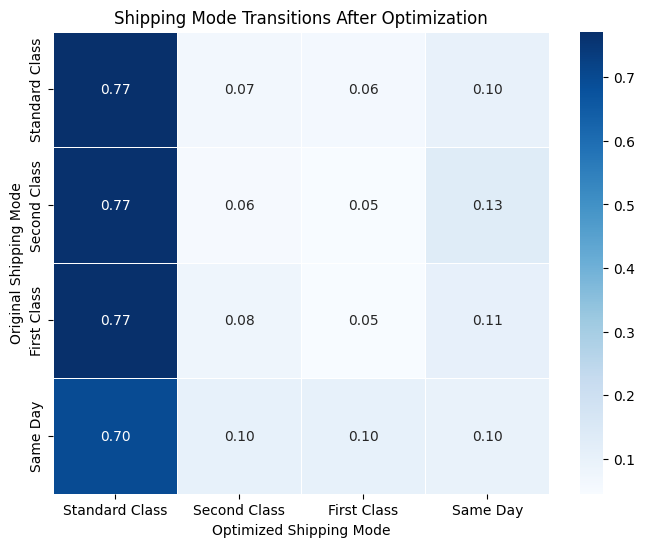

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Shipping Mode Transitions After Optimization")
plt.xlabel("Optimized Shipping Mode")
plt.ylabel("Original Shipping Mode")
plt.show()


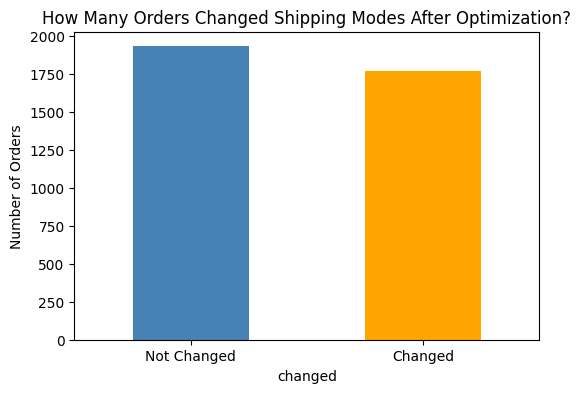

In [20]:
import matplotlib.pyplot as plt

# True if mode changed
comparison_df["changed"] = comparison_df["original_mode"] != comparison_df["optimized_mode"]

counts = comparison_df["changed"].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar", color=["steelblue", "orange"])
plt.xticks([0,1], ["Not Changed", "Changed"], rotation=0)
plt.ylabel("Number of Orders")
plt.title("How Many Orders Changed Shipping Modes After Optimization?")
plt.show()


In [21]:
before_cost = []

for o in delay_prob_df.index:
    orig_mode = comparison_df.loc[o, "original_mode"]
    p = delay_prob_df.loc[o, orig_mode]
    cost = p * penalties[orig_mode]
    before_cost.append(cost)

before_cost = pd.Series(before_cost, index=delay_prob_df.index)

after_cost = []

for o in delay_prob_df.index:
    opt_mode = comparison_df.loc[o, "optimized_mode"]
    p = delay_prob_df.loc[o, opt_mode]
    cost = p * penalties[opt_mode]
    after_cost.append(cost)

after_cost = pd.Series(after_cost, index=delay_prob_df.index)


total_before = before_cost.sum()
total_after  = after_cost.sum()
savings = total_before - total_after

summary_df = pd.DataFrame({
    "Total Before Optimization": [total_before],
    "Total After Optimization": [total_after],
    "Absolute Savings": [savings],
    "Percentage Savings (%)": [100 * savings / total_before]
})

summary_df


,Total Before Optimization,Total After Optimization,Absolute Savings,Percentage Savings (%)
0,2022.768252,1096.533299,926.234953,45.790463


In [22]:
import plotly.graph_objects as go

orig = comparison_df["original_mode"]
opt  = comparison_df["optimized_mode"]

# Unique modes
labels = shipping_modes

# Build source and target lists
source = []
target = []
value  = []

for i, o_mode in enumerate(labels):
    for j, t_mode in enumerate(labels):
        count = ((orig == o_mode) & (opt == t_mode)).sum()
        if count > 0:
            source.append(i)
            target.append(len(labels) + j)
            value.append(count)

# Combine labels for left + right sides
all_labels = labels + labels

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(label=all_labels, pad=20, thickness=20),
    link=dict(source=source, target=target, value=value)
))

fig.update_layout(title_text="Shipping Mode Flow: Before → After Optimization")
fig.show()
